# Returns and Risk Analysis

In portfolio management, stock prices alone are not sufficient for comparison because stocks trade at different price levels.

Instead, we analyze:

- Returns: How much an investment grows or declines.
- Volatility: How much returns fluctuate over time.
- Risk-Return Tradeoff: The relationship between potential reward and uncertainty.

This notebook calculates daily returns, annualized returns, and annualized volatility for selected stocks.

In [52]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [53]:
data = pd.read_csv(
    '../data/stock_prices.csv')

In [54]:
stocks = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL']

In [55]:
print(data.head(10))

         Date       AAPL       AMZN      GOOGL       MSFT      NVDA
0  2019-01-02  37.469200  76.956497  52.270512  94.193161  3.373053
1  2019-01-03  33.736984  75.014000  50.822834  90.727974  3.169262
2  2019-01-04  35.177208  78.769501  53.429722  94.947655  3.372309
3  2019-01-07  35.098904  81.475502  53.323174  95.068748  3.550841
4  2019-01-08  35.767998  82.829002  53.791519  95.758064  3.462443
5  2019-01-09  36.375408  82.971001  53.607155  97.127357  3.530537
6  2019-01-10  36.491657  82.810997  53.467396  96.503258  3.596156
7  2019-01-11  36.133385  82.028000  52.755699  95.758064  3.685299
8  2019-01-14  35.590042  80.860497  52.113396  95.059418  3.725165
9  2019-01-15  36.318459  83.727997  53.848015  97.816681  3.711051


In [56]:
data.dtypes

Date         str
AAPL     float64
AMZN     float64
GOOGL    float64
MSFT     float64
NVDA     float64
dtype: object

In [57]:
#Convert date into the index

data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace = True)
print(data.head())
print(data.dtypes)

                 AAPL       AMZN      GOOGL       MSFT      NVDA
Date                                                            
2019-01-02  37.469200  76.956497  52.270512  94.193161  3.373053
2019-01-03  33.736984  75.014000  50.822834  90.727974  3.169262
2019-01-04  35.177208  78.769501  53.429722  94.947655  3.372309
2019-01-07  35.098904  81.475502  53.323174  95.068748  3.550841
2019-01-08  35.767998  82.829002  53.791519  95.758064  3.462443
AAPL     float64
AMZN     float64
GOOGL    float64
MSFT     float64
NVDA     float64
dtype: object


## Daily Returns

Daily return measures the percentage change in stock price from one trading day to the next.

Formula:

Return = (Today's Price − Yesterday's Price) / Yesterday's Price

Positive values indicate gains, while negative values indicate losses.

Daily returns are the foundation for calculating risk, expected return, and portfolio performance.

Returns provide a normalized measure of performance and allow meaningful comparisons between assets with different price levels.

In [58]:
returns = data.pct_change() #computes the percentage change between consecutive rows

returns.head()

,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2019-01-02,NaN,NaN,NaN,NaN,NaN
2019-01-03,-0.099608,-0.025241,-0.027696,-0.036788,-0.060417
2019-01-04,0.042690,0.050064,0.051294,0.046509,0.064068
2019-01-07,-0.002226,0.034353,-0.001994,0.001275,0.052941
2019-01-08,0.019063,0.016612,0.008783,0.007251,-0.024895


In [59]:
#remove missing values
returns = returns.dropna()
returns.head()

,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2019-01-03,-0.099608,-0.025241,-0.027696,-0.036788,-0.060417
2019-01-04,0.042690,0.050064,0.051294,0.046509,0.064068
2019-01-07,-0.002226,0.034353,-0.001994,0.001275,0.052941
2019-01-08,0.019063,0.016612,0.008783,0.007251,-0.024895
2019-01-09,0.016982,0.001714,-0.003427,0.014300,0.019667


## Handling Missing Values

The first observation does not have a previous trading day available for return calculation.

This results in a missing value (NaN), which is removed before further analysis.

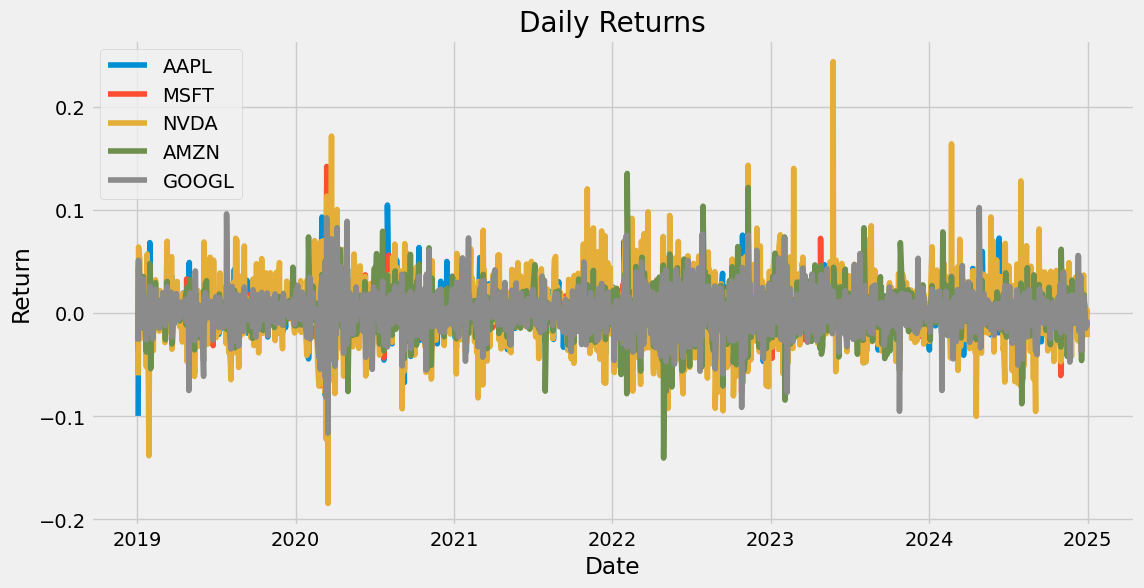

In [75]:
#plot daily returns

plt.figure(figsize = (12,6))

for stock in stocks:
    plt.plot(returns[stock], label = stock)

plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()

plt.savefig('../images/daily_returns.png', bbox_inches = 'tight')

plt.show()

## Visualization of Daily Returns

Unlike stock prices, returns fluctuate around zero.

The magnitude of these fluctuations provides an initial indication of risk.

Stocks exhibiting larger swings in returns are generally considered more volatile and therefore riskier.

## Annualized Return

In [61]:
annual_returns = returns.mean() * 252

annual_returns

AAPL     0.363900
AMZN     0.233196
GOOGL    0.262819
MSFT     0.290452
NVDA     0.749294
dtype: float64

## Annualized Return

There are roughly 252 trading days/year

Annual Return = Average Daily Return x 252

Annualized return estimates the expected yearly return based on the historical average daily return.

A higher annualized return indicates greater potential reward for investors.

## Annualized Volatility

In [62]:
annual_volatility = returns.std() * np.sqrt(252)

annual_volatility

AAPL     0.308397
AMZN     0.341296
GOOGL    0.312056
MSFT     0.289971
NVDA     0.518871
dtype: float64

## Annualized Volatility

Volatility measures the variability of returns around their average value.

In finance, volatility is commonly used as a measure of risk.

Daily volatility is annualized by multiplying by the square root of the number of trading days in a year (252).

Higher volatility implies greater uncertainty and larger fluctuations in portfolio value.

## Risk-Return Table

In [63]:
summary = pd.DataFrame({
    'Annual Return' : annual_returns,
    'Annual Volatility' : annual_volatility
})

summary

,Annual Return,Annual Volatility
AAPL,0.363900,0.308397
AMZN,0.233196,0.341296
GOOGL,0.262819,0.312056
MSFT,0.290452,0.289971
NVDA,0.749294,0.518871


In [64]:
summary.sort_values(
    by = 'Annual Return',
    ascending = False
)

,Annual Return,Annual Volatility
NVDA,0.749294,0.518871
AAPL,0.363900,0.308397
MSFT,0.290452,0.289971
GOOGL,0.262819,0.312056
AMZN,0.233196,0.341296


Portfolio construction requires considering both return and risk. Although NVIDIA achieved the highest return, it also exhibited substantially higher volatility. A diversified portfolio may provide a better risk-adjusted outcome.

# Correlation Analysis

Correlation measures the degree to which two assets move together.

Correlation values range between:

- +1 : Perfect positive relationship
- 0 : No relationship
- -1 : Perfect negative relationship

Portfolio diversification benefits arise when assets are not perfectly positively correlated.

In [66]:
correlation_matrix = returns.corr()

correlation_matrix

,AAPL,AMZN,GOOGL,MSFT,NVDA
AAPL,1.000000,0.590568,0.638709,0.734542,0.603474
AMZN,0.590568,1.000000,0.644628,0.681954,0.578063
GOOGL,0.638709,0.644628,1.000000,0.736548,0.580437
MSFT,0.734542,0.681954,0.736548,1.000000,0.671140
NVDA,0.603474,0.578063,0.580437,0.671140,1.000000


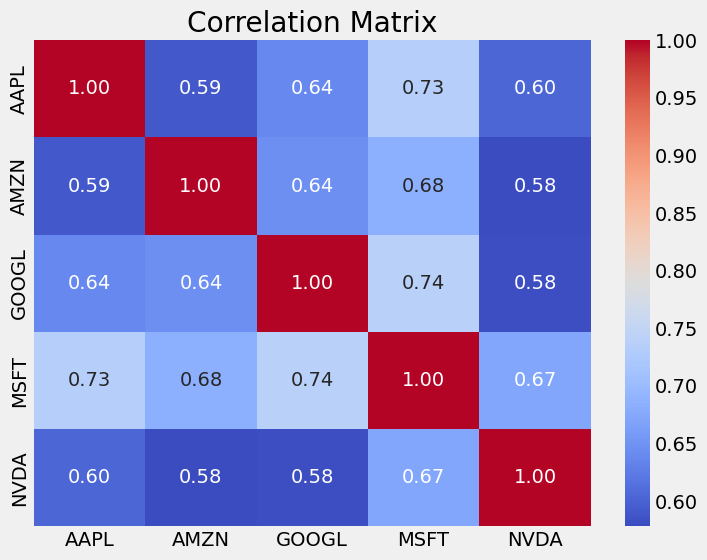

In [71]:
import seaborn as sns

plt.figure(figsize = (8,6))

sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f'
)

plt.title('Correlation Matrix')
plt.show()

## Interpretation of Correlation Matrix

All selected stocks exhibit positive correlations, indicating that they generally move in the same direction.

However, correlations remain below 1, implying that the assets are not perfectly synchronized. This creates diversification opportunities, allowing portfolio risk to be reduced by combining multiple assets.

Lower correlation values indicate greater diversification benefits and play a critical role in portfolio optimization.

## Covariance Matrix

In [ ]:
covariance_matrix = returns.cov() * 252 #Annual Covariance

covariance_matrix

,AAPL,AMZN,GOOGL,MSFT,NVDA
AAPL,0.095109,0.062160,0.061468,0.065687,0.096567
AMZN,0.062160,0.116483,0.068655,0.067490,0.102368
GOOGL,0.061468,0.068655,0.097379,0.066648,0.093982
MSFT,0.065687,0.067490,0.066648,0.084083,0.100978
NVDA,0.096567,0.102368,0.093982,0.100978,0.269227


## Covariance Matrix

Covariance measures how two assets move together and captures both direction and magnitude of their relationship.

Positive covariance indicates that assets tend to move in the same direction, while negative covariance suggests opposite movements.

The covariance matrix is a key input for portfolio optimization because portfolio risk depends not only on individual asset volatility but also on how assets interact with one another.

Diagonal elements represent variances of individual assets, while off-diagonal elements represent pairwise covariances.